In [2]:
# Data analysis 
# import python libraries

import pandas as pd
import hvplot.pandas
import holoviews as hv
import matplotlib.pyplot as plt
print("Imports successful!")


Imports successful!


In [ ]:
# Create an API call to the NOAA NCEI database
ncei_url = ('https://www.ncei.noaa.gov/access/services/data/v1'
           '?dataset=daily-summaries'
           '&dataTypes=TOBS'
           '&stations=USC00050848'
           '&startDate=1893-10-01'
           '&endDate=2026-07-15'
           '&units=standard')
ncei_url


'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00050848&startDate=1893-10-01&endDate=2026-07-15&units=standard'

In [4]:
# Open and clean the data
boulder_df = pd.read_csv(
    ncei_url,
    na_values=["-99"],
    index_col="DATE",
    parse_dates=["DATE"]
)
boulder_df


,STATION,TOBS
DATE,,
1893-10-01,USC00050848,NaN
1893-10-02,USC00050848,NaN
1893-10-03,USC00050848,NaN
1893-10-04,USC00050848,NaN
1893-10-05,USC00050848,NaN
...,...,...
2026-07-11,USC00050848,91.0
2026-07-12,USC00050848,95.0
2026-07-13,USC00050848,95.0


In [7]:
# Keep only the TOBS column
boulder_df = boulder_df[["TOBS"]]

# calling method python will only run last method called
boulder_df.head()
boulder_df.tail()

,TOBS
DATE,
2026-07-11,91.0
2026-07-12,95.0
2026-07-13,95.0
2026-07-14,95.0
2026-07-15,90.0


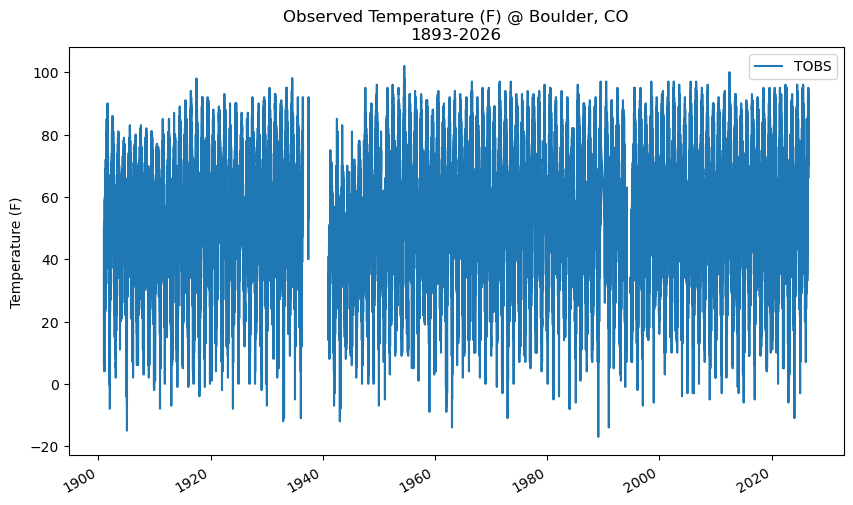

In [8]:
# Plot data with matplotlib
fig, ax = plt.subplots(figsize=(10,6))
boulder_df.plot(y='TOBS',
                 ax=ax,
                 ylabel='Temperature (F)',
                 xlabel='',
                 title='Observed Temperature (F) @ Boulder, CO\n1893-2026')
plt.show()

In [9]:
# Take the annual mean of the temperature data, ye equals year end
ann_climate_df = boulder_df.resample('YE').mean()
ann_climate_df

,TOBS
DATE,
1893-12-31,NaN
1894-12-31,NaN
1895-12-31,NaN
1896-12-31,NaN
1897-12-31,NaN
...,...
2022-12-31,56.139726
2023-12-31,55.694215
2024-12-31,57.991758


<Axes: xlabel='DATE'>

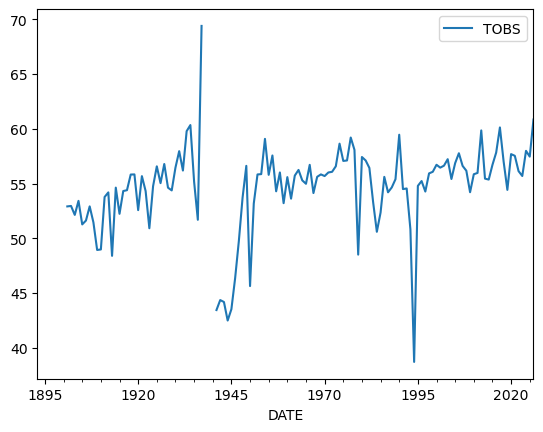

In [10]:
# Plot resampled the data
ann_climate_df.plot()

In [12]:
# Subset the data to look at last 30 years of data, referencing year end means
boulder_30yr = ann_climate_df.loc["1995":"2025"]
boulder_30yr

,TOBS
DATE,
1995-12-31,54.792818
1996-12-31,55.233516
1997-12-31,54.274725
1998-12-31,55.931507
1999-12-31,56.079452
2000-12-31,56.719780
2001-12-31,56.457534
2002-12-31,56.638356
2003-12-31,57.230137


<Axes: xlabel='DATE'>

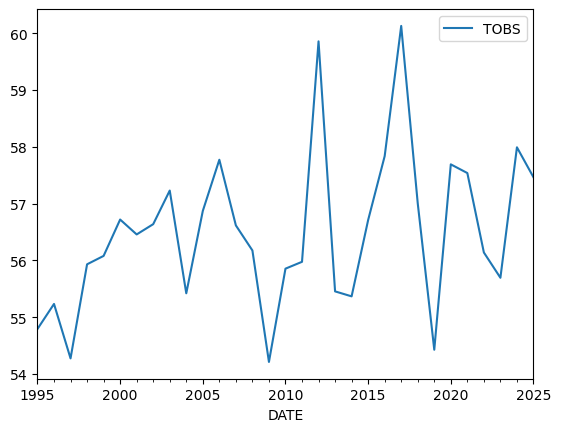

In [13]:
# Plot 30 yrs of data with year end mean
boulder_30yr.plot()

In [14]:
# Create an interactive plot with hvplot
boulder_30yr_plot = boulder_30yr.hvplot()
boulder_30yr_plot

:Curve   [DATE]   (TOBS)

In [15]:
# Save interactive plot as html to host on the web
hv.save(boulder_30yr_plot, 'boulder_plot.html')